In [1]:
from maze_nca.config import EnvConfig
from maze_nca.nca import NCAModel
from maze_nca.task_generation import generate_task
from maze_nca.utils import plot_channel, benchmark_reward
import tensorflow as tf

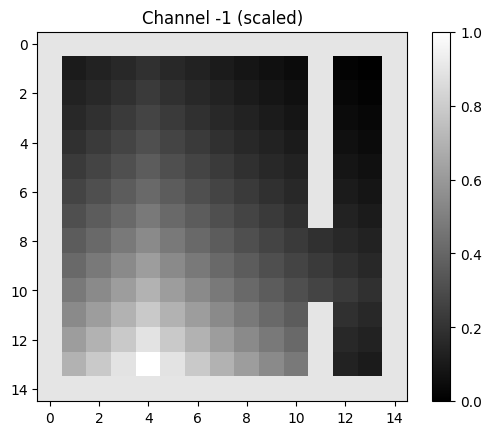

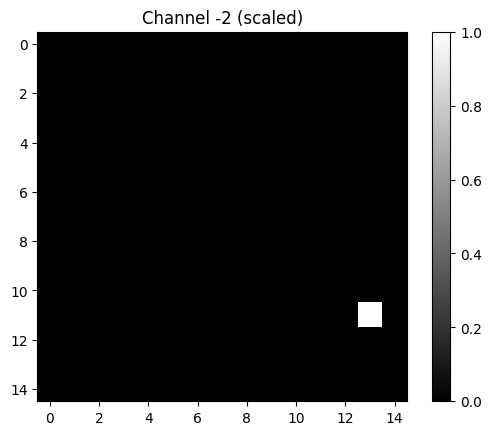

In [4]:
# Visualize Channels
config = EnvConfig()
ca = NCAModel(
    living_channels=8,
    num_neurons=64,
    death_threshold=0.05
)
env = generate_task(
    config.to_tf_task_cfg(),
    seed=tf.constant([1, 1], dtype=tf.int32)
)
env = ca.egg(env, config)
plot_channel(env, -1)
plot_channel(env, -2)

In [ ]:
config = EnvConfig(
    activity_cost=5,
    VI_goal_reward=0,
    VI_step_cost=1,
    reward_temperature=1e-1,
    alive_scaled=False,
    max_height=10,
    max_width=10,
)

ca = NCAModel(
    living_channels=8,
    num_neurons=64,
    death_threshold=0.05
)

benchmark_reward(
    config,
    ca,
    batch_size=10,
    base_seed=tf.constant([123, 456], dtype=tf.int32)
)


    Starting Reward: 9.216116836309793e-17
    Goal Reward: 0.3968239426612854
    Space-Filled Reward: 0.008044971153140068
    Half-Space-Filled Reward: 0.008044971153140068
    Self-Destruct Reward: 0.0
    
